
# Unsupervised Learning Lab: Customer Segmentation

## Introduction
Welcome to the Unsupervised Learning lab. You will perform customer segmentation using unsupervised learning techniques on customer data from a store. You will read the dataset using pandas and apply various clustering algorithms to segment the customers.

### Dataset
The dataset contains the following columns:
- `CustomerID`: Unique identifier for each customer
- `Age`: Age of the customer
- `AnnualIncome`: Annual income of the customer in dollars
- `SpendingScore`: A score assigned to the customer based on their spending behavior

### Instructions
1. Follow the steps in each exercise to preprocess the data, apply the clustering algorithms, and visualize the results.
2. Analyze the clusters and interpret the results.


## Exercise 1: Data Preprocessing and Exploration
1. Load the dataset using pandas.
2. Explore the dataset to understand its structure and contents.
3. Perform basic data cleaning, if necessary (e.g., handling missing values, if any).
4. Standardize the numerical features to ensure they are on a similar scale.

In [21]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler

df = pd.read_csv("C:\\Users\\ramya\\Downloads\\customer_data.csv")
df

,CustomerID,Age,AnnualIncome,SpendingScore
0,1,56,81228,59
1,2,69,68984,32
2,3,46,60774,96
3,4,32,22568,88
4,5,60,82592,52
...,...,...,...,...
95,96,42,117504,24
96,97,62,118098,54
97,98,58,33545,33
98,99,46,86199,24


In [22]:
df.describe()

,CustomerID,Age,AnnualIncome,SpendingScore
count,100.000000,100.000000,100.000000,100.000000
mean,50.500000,43.350000,69474.690000,48.760000
std,29.011492,14.904663,29863.619229,31.064976
min,1.000000,19.000000,20206.000000,1.000000
25%,25.750000,31.750000,43229.750000,20.000000
50%,50.500000,42.000000,70325.500000,52.000000
75%,75.250000,57.000000,95529.000000,73.500000
max,100.000000,69.000000,118806.000000,99.000000


In [23]:
df = df.drop(columns = ['CustomerID'])

In [24]:
df.isnull().sum()

Age              0
AnnualIncome     0
SpendingScore    0
dtype: int64

In [25]:
df_scaled = StandardScaler().fit_transform(df)

In [26]:
df = pd.DataFrame(df_scaled, columns = df.columns)

In [27]:
df

,Age,AnnualIncome,SpendingScore
0,0.853003,0.395549,0.331292
1,1.729608,-0.016514,-0.542232
2,0.178692,-0.292815,1.528345
3,-0.765343,-1.578610,1.269522
4,1.122728,0.441453,0.104823
...,...,...,...
95,-0.091032,1.616391,-0.801054
96,1.257590,1.636381,0.169528
97,0.987866,-1.209187,-0.509880
98,0.178692,0.562844,-0.801054


## Exercise 2: K-Means Clustering
1. Apply K-Means clustering to segment the customers based on their `Age`, `AnnualIncome`, and `SpendingScore`.
2. Determine the optimal number of clusters using the Elbow method.
3. Visualize the clusters using scatter plots.

In [28]:
from sklearn import cluster, datasets
from sklearn.preprocessing import StandardScaler
from matplotlib.lines import Line2D

In [29]:
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans

kmeans = cluster.KMeans(n_clusters=4, random_state=0)
kmeans.fit(df)
pred = kmeans.predict(df)
pred

C:\Users\ramya\anaconda3\lib\site-packages\sklearn\cluster\_kmeans.py:1429: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(


array([1, 3, 1, 2, 3, 0, 2, 3, 2, 0, 0, 0, 2, 1, 2, 3, 2, 2, 0, 1, 1, 2,
       3, 0, 0, 1, 2, 1, 3, 1, 3, 1, 2, 2, 0, 0, 3, 3, 1, 1, 0, 1, 3, 0,
       2, 0, 1, 2, 2, 1, 0, 3, 2, 0, 0, 1, 1, 3, 0, 1, 0, 3, 3, 2, 0, 1,
       3, 3, 2, 0, 0, 3, 0, 3, 1, 2, 1, 3, 0, 2, 2, 3, 3, 2, 0, 0, 2, 3,
       0, 2, 3, 2, 2, 0, 2, 0, 1, 3, 3, 2])

In [30]:
pred = pd.DataFrame(pred, columns = ['pred'])

In [31]:
pred

,pred
0,1
1,3
2,1
3,2
4,3
...,...
95,0
96,1
97,3
98,3


In [32]:
df['KMcluster'] = pred

In [33]:
df

,Age,AnnualIncome,SpendingScore,KMcluster
0,0.853003,0.395549,0.331292,1
1,1.729608,-0.016514,-0.542232,3
2,0.178692,-0.292815,1.528345,1
3,-0.765343,-1.578610,1.269522,2
4,1.122728,0.441453,0.104823,3
...,...,...,...,...
95,-0.091032,1.616391,-0.801054,0
96,1.257590,1.636381,0.169528,1
97,0.987866,-1.209187,-0.509880,3
98,0.178692,0.562844,-0.801054,3


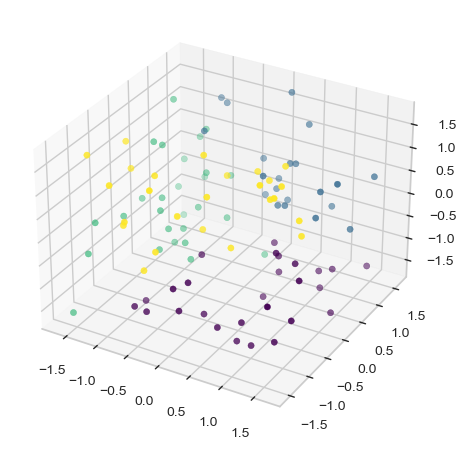

<Figure size 500x500 with 0 Axes>

Model 1 Silhouette Score: 0.3918482049827708


C:\Users\ramya\anaconda3\lib\site-packages\sklearn\utils\validation.py:1339: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


In [35]:
from mpl_toolkits import mplot3d
ax = plt.axes(projection ="3d")
plt.figure(figsize=(5, 5))
ax.scatter3D(df['AnnualIncome'], df['SpendingScore'], df['Age'],c=df['KMcluster'], cmap='viridis')
plt.show()

from yellowbrick.cluster import KElbowVisualizer
from sklearn.metrics import silhouette_score
print("Model 1 Silhouette Score: {}".format(silhouette_score(df, pred, metric='euclidean')))

C:\Users\ramya\anaconda3\lib\site-packages\sklearn\cluster\_kmeans.py:1429: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
C:\Users\ramya\anaconda3\lib\site-packages\sklearn\cluster\_kmeans.py:1429: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
C:\Users\ramya\anaconda3\lib\site-packages\sklearn\cluster\_kmeans.py:1429: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
C:\Users\ramya\anaconda3\lib\site-packages\sklearn\cluster\_kmeans.py:1429: UserWarning: KMeans is known to have a memory leak on Window

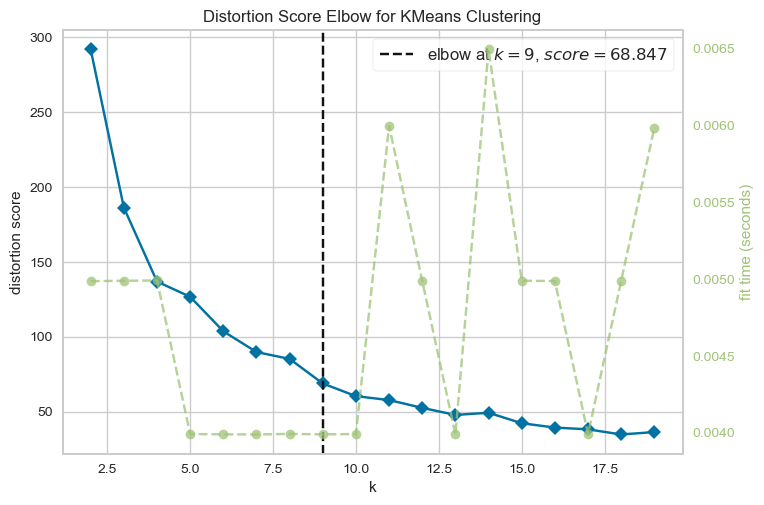

<AxesSubplot:title={'center':'Distortion Score Elbow for KMeans Clustering'}, xlabel='k', ylabel='distortion score'>

In [36]:
from yellowbrick.cluster import KElbowVisualizer

model = cluster.KMeans()
visualizer = KElbowVisualizer(model, k=(2,20))
visualizer.fit(df)
visualizer.poof()

In [37]:
kmeans = cluster.KMeans(n_clusters=9, random_state=0)
kmeans.fit(df)
pred = kmeans.predict(df)
df['elbow_cluster'] = pred
df

C:\Users\ramya\anaconda3\lib\site-packages\sklearn\cluster\_kmeans.py:1429: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(


,Age,AnnualIncome,SpendingScore,KMcluster,elbow_cluster
0,0.853003,0.395549,0.331292,1,7
1,1.729608,-0.016514,-0.542232,3,5
2,0.178692,-0.292815,1.528345,1,7
3,-0.765343,-1.578610,1.269522,2,3
4,1.122728,0.441453,0.104823,3,5
...,...,...,...,...,...
95,-0.091032,1.616391,-0.801054,0,4
96,1.257590,1.636381,0.169528,1,7
97,0.987866,-1.209187,-0.509880,3,1
98,0.178692,0.562844,-0.801054,3,5


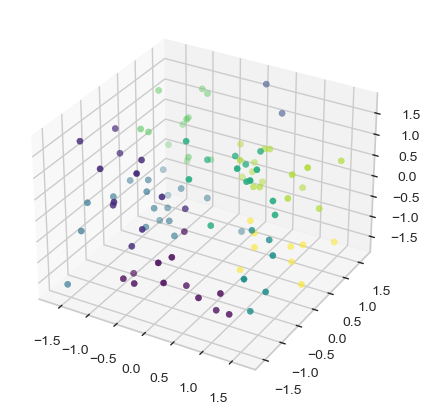

Model 1 Silhouette Score: 0.5939234830927803


In [43]:
plt.figure(figsize=(5, 5))
ax = plt.axes(projection ="3d")
ax.scatter3D(df['AnnualIncome'], df['SpendingScore'],df['Age'], c=df['elbow_cluster'], cmap='viridis')
plt.show()
print("Model 1 Silhouette Score: {}".format(silhouette_score(df, pred, metric='euclidean')))

## Exercise 3: Hierarchical Clustering
1. Apply Agglomerative Hierarchical Clustering to the same features.
2. Use a dendrogram to determine the optimal number of clusters.
3. Visualize the clusters using scatter plots.

In [44]:
from scipy.cluster.hierarchy import dendrogram, linkage
from sklearn.cluster import AgglomerativeClustering

In [45]:
agglomerative = cluster.AgglomerativeClustering(n_clusters=3,linkage='ward')

In [46]:
df1 = pd.read_csv("C:\\Users\\ramya\\Downloads\\customer_data.csv")
df1

,CustomerID,Age,AnnualIncome,SpendingScore
0,1,56,81228,59
1,2,69,68984,32
2,3,46,60774,96
3,4,32,22568,88
4,5,60,82592,52
...,...,...,...,...
95,96,42,117504,24
96,97,62,118098,54
97,98,58,33545,33
98,99,46,86199,24


In [47]:
df1 = df1.drop(columns = ['CustomerID'])
df_scaled1 = StandardScaler().fit_transform(df1)

df1 = pd.DataFrame(df_scaled1, columns = df1.columns)

df1

,Age,AnnualIncome,SpendingScore
0,0.853003,0.395549,0.331292
1,1.729608,-0.016514,-0.542232
2,0.178692,-0.292815,1.528345
3,-0.765343,-1.578610,1.269522
4,1.122728,0.441453,0.104823
...,...,...,...
95,-0.091032,1.616391,-0.801054
96,1.257590,1.636381,0.169528
97,0.987866,-1.209187,-0.509880
98,0.178692,0.562844,-0.801054


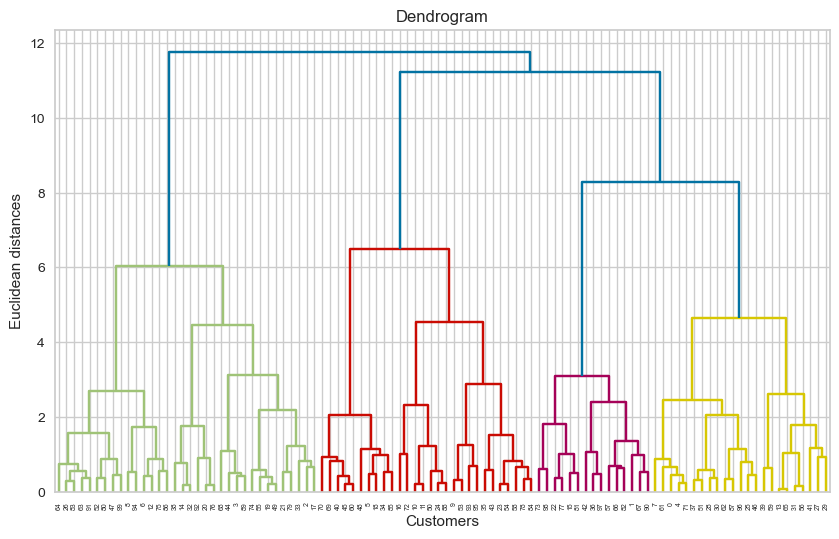

In [50]:
Z = linkage(df1[['Age', 'AnnualIncome', 'SpendingScore']], method='ward')

plt.figure(figsize=(10, 6))
dendrogram(Z)
plt.title('Dendrogram')
plt.xlabel('Customers')
plt.ylabel('Euclidean distances')
plt.show()

In [48]:
pred_agg = agglomerative.fit_predict(df1)
pred_agg

array([0, 0, 1, 1, 0, 2, 1, 0, 1, 2, 2, 2, 1, 0, 1, 0, 2, 1, 2, 1, 1, 1,
       0, 2, 2, 0, 1, 0, 0, 0, 0, 0, 1, 1, 2, 2, 0, 0, 1, 0, 2, 0, 0, 2,
       1, 2, 0, 1, 2, 1, 2, 0, 1, 2, 2, 1, 0, 0, 2, 0, 2, 0, 0, 1, 1, 0,
       0, 0, 1, 2, 2, 0, 2, 0, 1, 1, 1, 0, 2, 1, 1, 0, 0, 1, 2, 2, 1, 0,
       2, 1, 0, 1, 1, 2, 1, 2, 0, 0, 0, 1], dtype=int64)

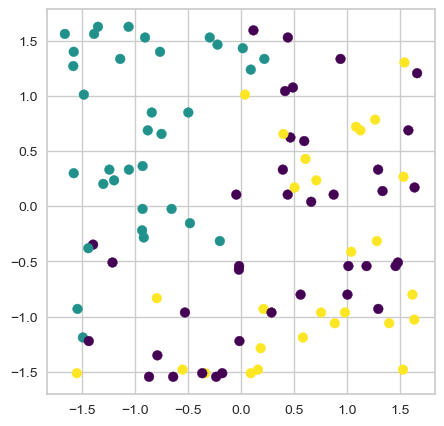

In [49]:
plt.figure(figsize=(5, 5))
plt.scatter(df1['AnnualIncome'], df1['SpendingScore'], c=pred_agg, cmap='viridis')
plt.show()

## Exercise 4: DBSCAN Clustering
1. Apply DBSCAN clustering to the same features.
2. Experiment with different values of `eps` and `min_samples` to find the best clustering results.
3. Visualize the clusters using scatter plots.

In [46]:
df

,Age,AnnualIncome,SpendingScore,cluster
0,0.853003,0.395549,0.331292,1
1,1.729608,-0.016514,-0.542232,1
2,0.178692,-0.292815,1.528345,2
3,-0.765343,-1.578610,1.269522,2
4,1.122728,0.441453,0.104823,1
...,...,...,...,...
95,-0.091032,1.616391,-0.801054,0
96,1.257590,1.636381,0.169528,1
97,0.987866,-1.209187,-0.509880,2
98,0.178692,0.562844,-0.801054,1


In [62]:
from sklearn.cluster import DBSCAN

dbscan = DBSCAN(eps=0.5, min_samples=4)
df['DBSCAN_Cluster'] = dbscan.fit_predict(df[['Age', 'AnnualIncome', 'SpendingScore']])
df['DBSCAN_Cluster'].unique()

array([ 0, -1,  3,  1,  2,  4], dtype=int64)

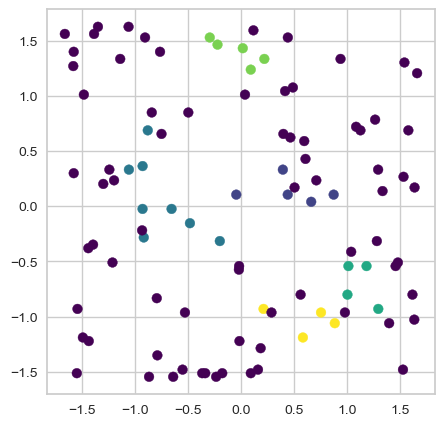

In [63]:
plt.figure(figsize=(5, 5))
plt.scatter(df1['AnnualIncome'], df1['SpendingScore'], c=df['DBSCAN_Cluster'], cmap='viridis')
plt.show()